# Customer Churn Prediction & Explainable AI

## Business Problem

Telecommunication companies lose millions of dollars annually due to customer churn.

Retaining an existing customer is significantly more cost-effective than acquiring a new one.

This project aims to develop an explainable machine learning solution capable of identifying customers likely to churn, enabling proactive retention strategies.

---

## Objectives

- Perform exploratory data analysis (EDA)
- Identify major churn drivers
- Build predictive machine learning models
- Compare model performance
- Explain model predictions using SHAP
- Generate business recommendations for customer retention

---

## Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- SHAP

# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import shap

import joblib

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print(" All libraries imported successfully.")

 All libraries imported successfully.


# 2. Load Dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 7043
Number of Columns : 21


# 3. Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [9]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [10]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [11]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [13]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Duplicate Records",
        "Missing Values",
        "Target Variable"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        "Churn"
    ]
})

summary

,Metric,Value
0,Number of Rows,7043
1,Number of Columns,21
2,Duplicate Records,0
3,Missing Values,0
4,Target Variable,Churn


# 4. Data Cleaning

In [14]:
df_clean = df.copy()

print("Working copy created successfully.")

Working copy created successfully.


In [15]:
df_clean.drop(columns="customerID", inplace=True)

print("customerID column removed.")

customerID column removed.


In [16]:
df_clean.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [17]:
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

In [18]:
df_clean.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [19]:
df_clean[df_clean["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [20]:
df_clean[df_clean["TotalCharges"].isnull()][["tenure","MonthlyCharges","TotalCharges","Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [21]:
df_clean.dropna(inplace=True)

print("Missing values removed successfully.")

Missing values removed successfully.


In [22]:
df_clean.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
df_clean["Churn"] = df_clean["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Target variable encoded successfully.")

Target variable encoded successfully.


In [24]:
df_clean["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [25]:
summary = pd.DataFrame({

    "Metric":[
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Records"
    ],

    "Value":[
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]

})

summary

,Metric,Value
0,Rows,7032
1,Columns,20
2,Missing Values,0
3,Duplicate Records,22


# 5. Exploratory Data Analysis(EDA)

## 5.1 Feature Selection

In [26]:
target = "Churn"

# Numerical Features
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# Binary Categorical Features
binary_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    target
]

# Multi-category Features
categorical_features = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

print(f"Numerical Features ({len(numerical_features)}):")
print(numerical_features)

print("\nBinary Features ({}):".format(len(binary_features)))
print(binary_features)

print("\nCategorical Features ({}):".format(len(categorical_features)))
print(categorical_features)

Numerical Features (3):
['tenure', 'MonthlyCharges', 'TotalCharges']

Binary Features (7):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

Categorical Features (10):
['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


## 5.2 Customer Churn Distribution

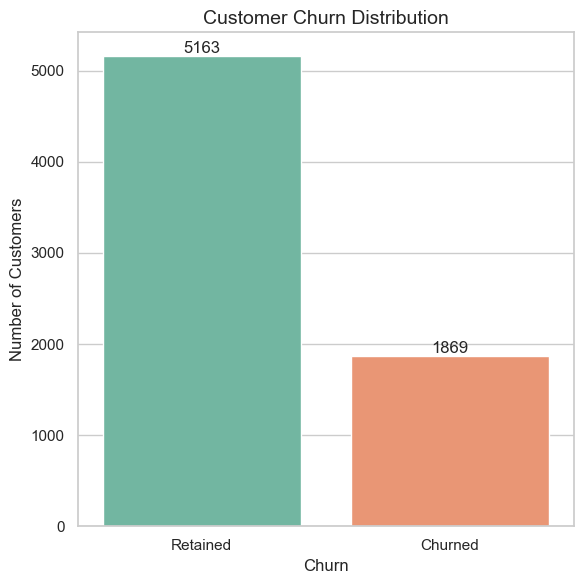

In [27]:
plt.figure(figsize=(6,6))

ax = sns.countplot(
    data=df_clean,
    x="Churn",
    palette="Set2"
)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.xticks([0,1],["Retained","Churned"])

plt.tight_layout()
plt.show()

In [28]:
churn_percentage = (
    df_clean["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_percentage

Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

## 5.3 Customer Demographics Analysis

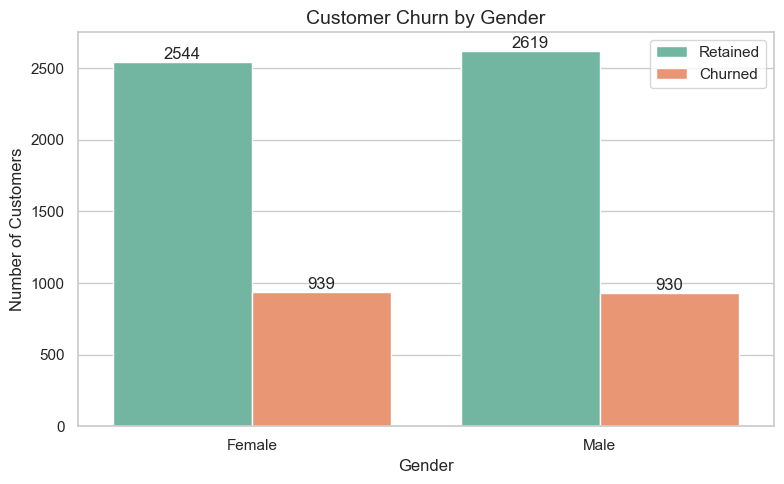

In [29]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="gender",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(["Retained","Churned"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

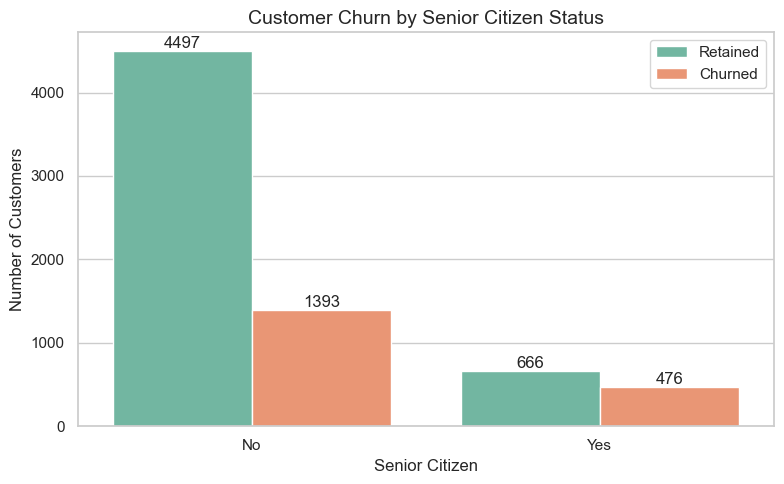

In [30]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="SeniorCitizen",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Senior Citizen Status", fontsize=14)
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.xticks([0,1],["No","Yes"])

plt.legend(["Retained","Churned"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

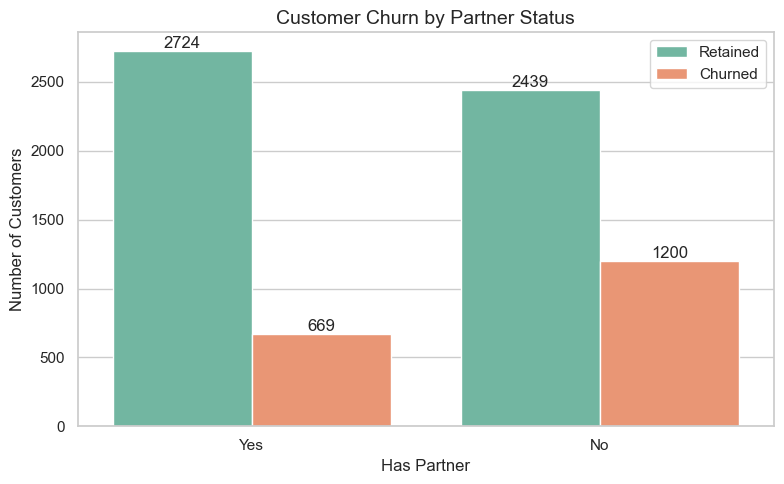

In [31]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="Partner",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Partner Status", fontsize=14)
plt.xlabel("Has Partner")
plt.ylabel("Number of Customers")

plt.legend(["Retained","Churned"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

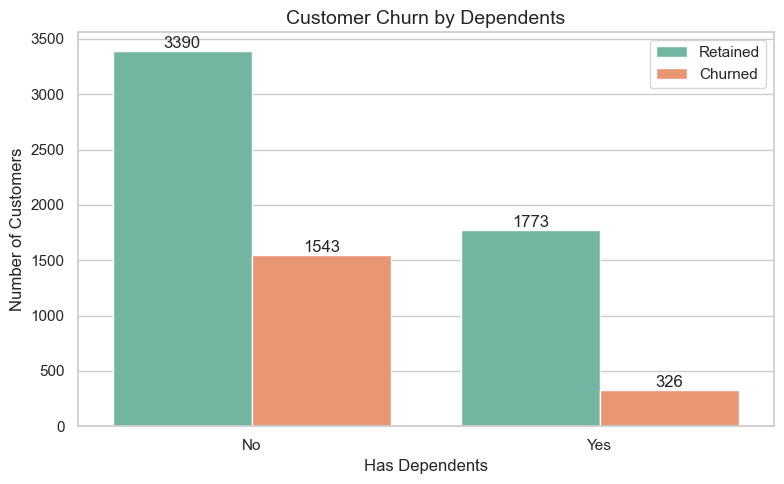

In [32]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="Dependents",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Dependents", fontsize=14)
plt.xlabel("Has Dependents")
plt.ylabel("Number of Customers")

plt.legend(["Retained","Churned"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [33]:
demographic_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

for feature in demographic_features:

    print("=" * 60)
    print(f"Churn Rate by {feature}\n")

    churn_rate = (
        df_clean
        .groupby(feature)["Churn"]
        .mean()
        .mul(100)
        .round(2)
    )

    print(churn_rate)
    print()

Churn Rate by gender

gender
Female    26.96
Male      26.20
Name: Churn, dtype: float64

Churn Rate by SeniorCitizen

SeniorCitizen
0    23.65
1    41.68
Name: Churn, dtype: float64

Churn Rate by Partner

Partner
No     32.98
Yes    19.72
Name: Churn, dtype: float64

Churn Rate by Dependents

Dependents
No     31.28
Yes    15.53
Name: Churn, dtype: float64



## 5.4 Customer Account Analysis

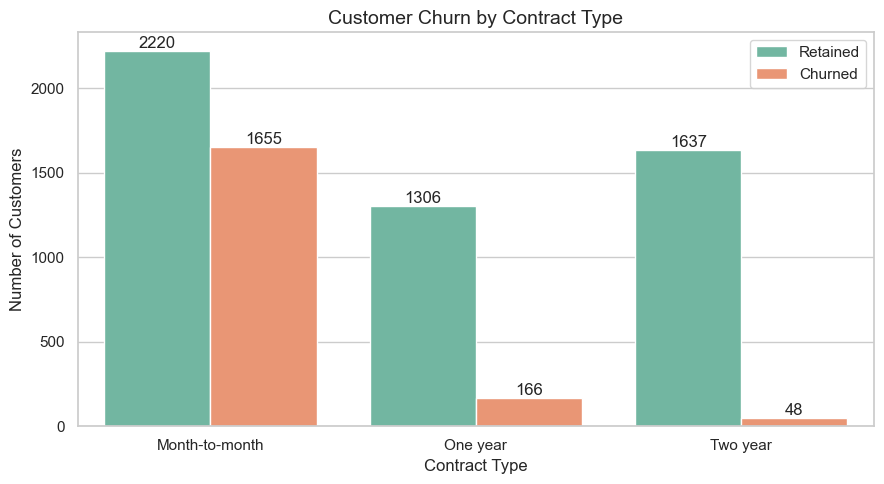

In [34]:
plt.figure(figsize=(9,5))

ax = sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Contract Type", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.legend(["Retained", "Churned"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [35]:
contract_churn = (
    df_clean
    .groupby("Contract")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

contract_churn

Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64

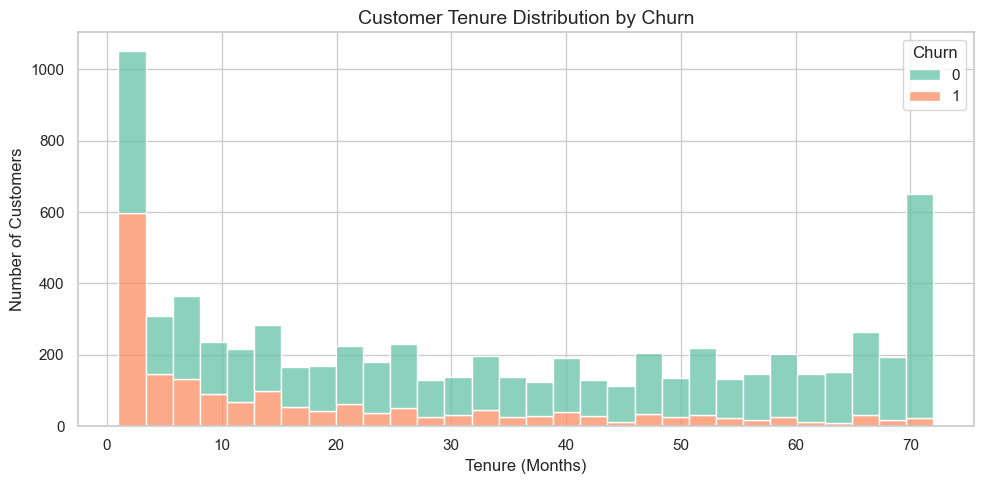

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_clean,
    x="tenure",
    hue="Churn",
    multiple="stack",
    bins=30,
    palette="Set2"
)

plt.title("Customer Tenure Distribution by Churn", fontsize=14)
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

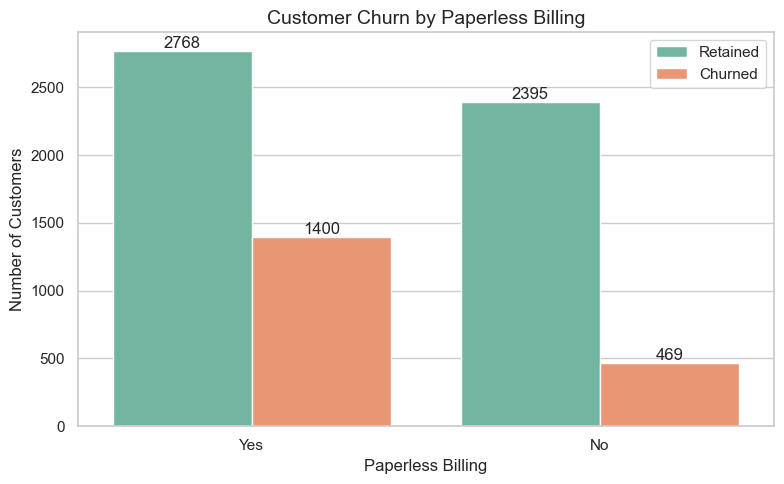

In [37]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="PaperlessBilling",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Paperless Billing", fontsize=14)
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")

plt.legend(["Retained", "Churned"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [38]:
paperless_churn = (
    df_clean
    .groupby("PaperlessBilling")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

paperless_churn

PaperlessBilling
No     16.38
Yes    33.59
Name: Churn, dtype: float64

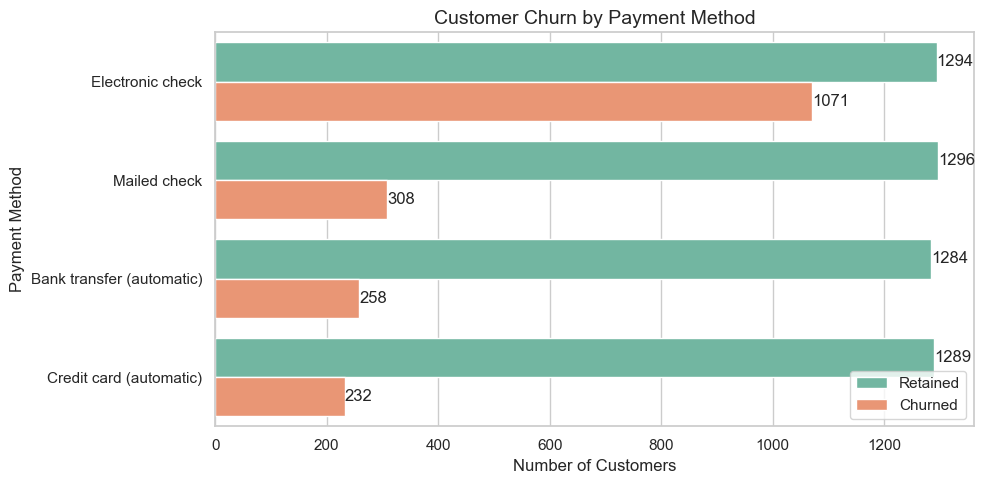

In [39]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df_clean,
    y="PaymentMethod",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Payment Method", fontsize=14)
plt.xlabel("Number of Customers")
plt.ylabel("Payment Method")

plt.legend(["Retained", "Churned"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [40]:
payment_churn = (
    df_clean
    .groupby("PaymentMethod")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

payment_churn

PaymentMethod
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Electronic check             45.29
Mailed check                 19.20
Name: Churn, dtype: float64

In [41]:
account_summary = pd.DataFrame({
    "Business Finding": [
        "Month-to-month contracts",
        "Short tenure customers",
        "Paperless billing users",
        "Electronic check users"
    ],
    "Risk Level": [
        "High",
        "High",
        "Medium",
        "High"
    ]
})

account_summary

,Business Finding,Risk Level
0,Month-to-month contracts,High
1,Short tenure customers,High
2,Paperless billing users,Medium
3,Electronic check users,High


## 5.5 Service Subscription Analysis

In [42]:
def plot_churn(feature):

    plt.figure(figsize=(9,5))

    ax = sns.countplot(
        data=df_clean,
        x=feature,
        hue="Churn",
        palette="Set2"
    )

    plt.title(f"Customer Churn by {feature}", fontsize=14)
    plt.xlabel(feature)
    plt.ylabel("Number of Customers")

    plt.legend(["Retained", "Churned"])

    for container in ax.containers:
        ax.bar_label(container)

    plt.xticks(rotation=15)

    plt.tight_layout()

    plt.show()

    churn_rate = (
        df_clean
        .groupby(feature)["Churn"]
        .mean()
        .mul(100)
        .round(2)
    )

    print("\nChurn Rate (%)")
    print(churn_rate)

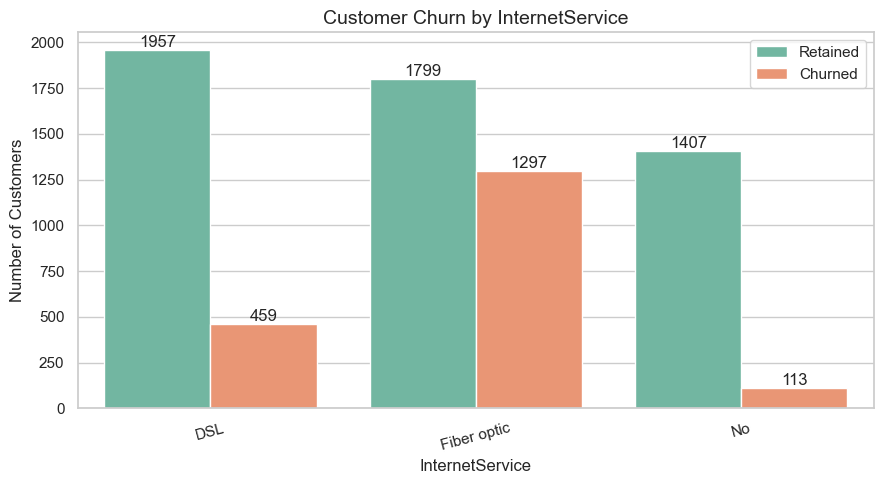


Churn Rate (%)
InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn, dtype: float64


In [43]:
plot_churn("InternetService")

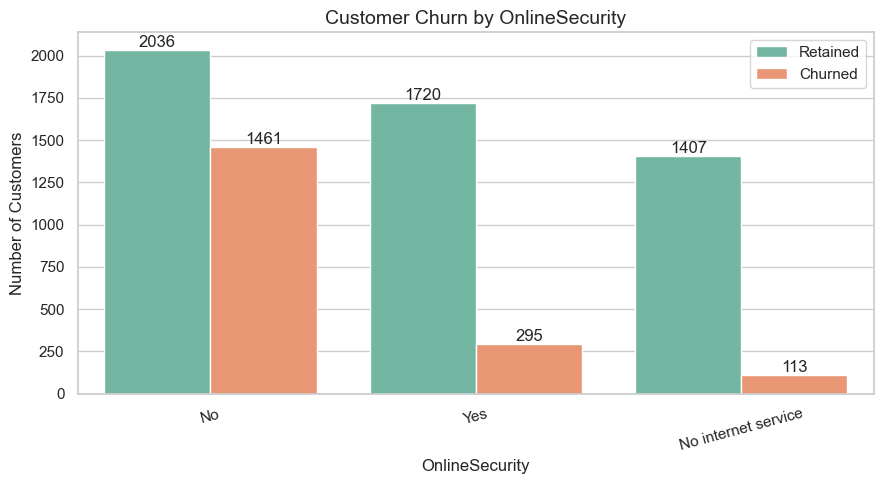


Churn Rate (%)
OnlineSecurity
No                     41.78
No internet service     7.43
Yes                    14.64
Name: Churn, dtype: float64


In [44]:
plot_churn("OnlineSecurity")

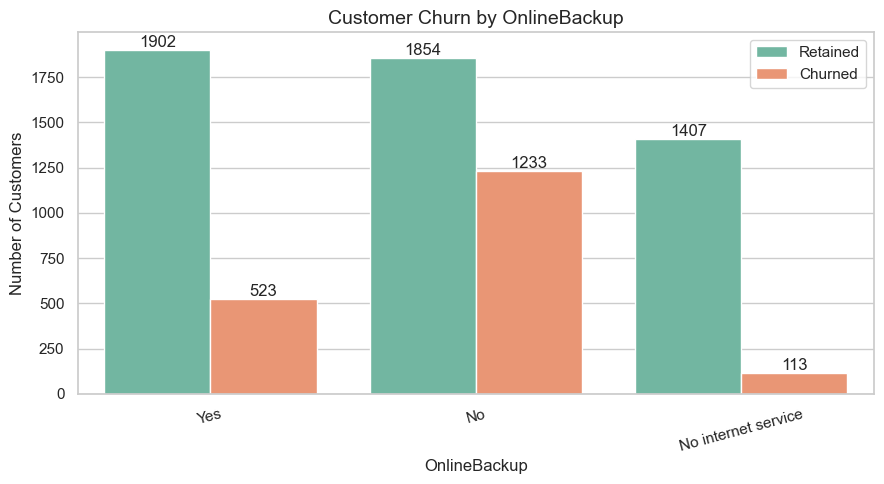


Churn Rate (%)
OnlineBackup
No                     39.94
No internet service     7.43
Yes                    21.57
Name: Churn, dtype: float64


In [45]:
plot_churn("OnlineBackup")

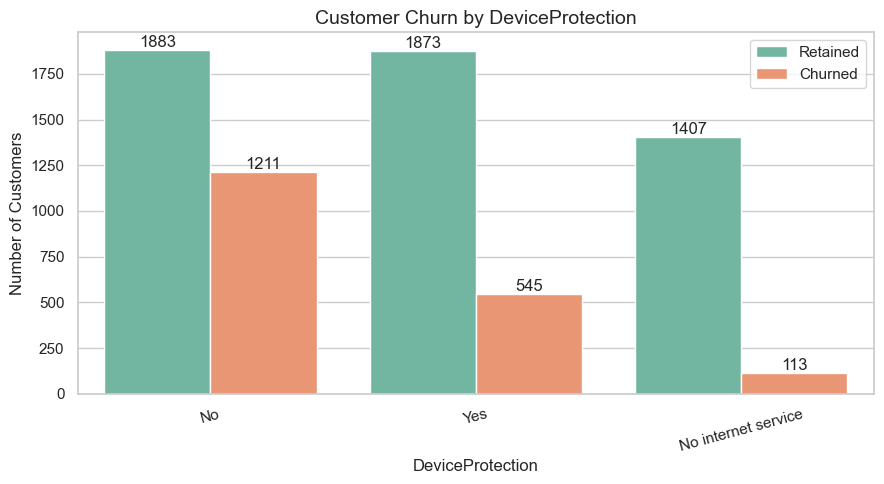


Churn Rate (%)
DeviceProtection
No                     39.14
No internet service     7.43
Yes                    22.54
Name: Churn, dtype: float64


In [46]:
plot_churn("DeviceProtection")

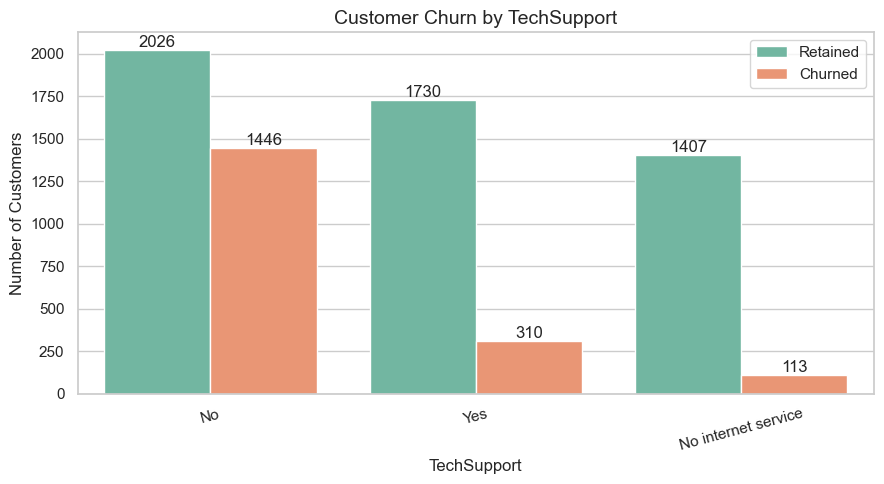


Churn Rate (%)
TechSupport
No                     41.65
No internet service     7.43
Yes                    15.20
Name: Churn, dtype: float64


In [47]:
plot_churn("TechSupport")

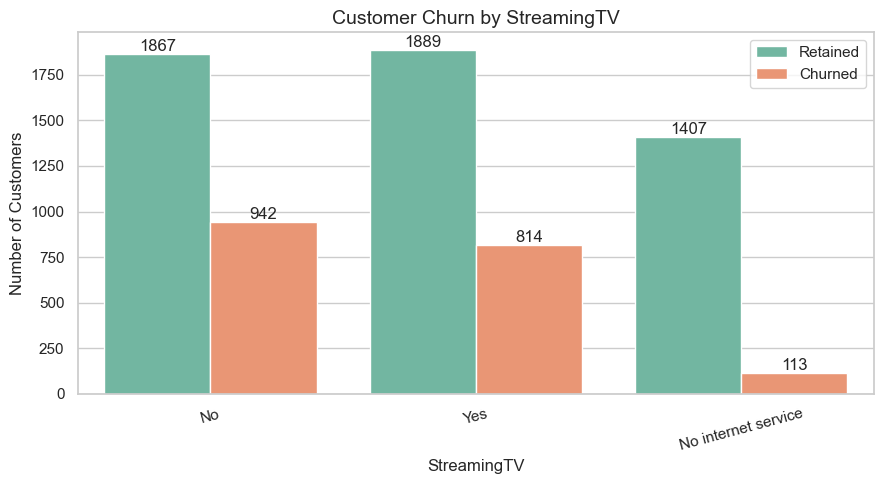


Churn Rate (%)
StreamingTV
No                     33.54
No internet service     7.43
Yes                    30.11
Name: Churn, dtype: float64


In [48]:
plot_churn("StreamingTV")

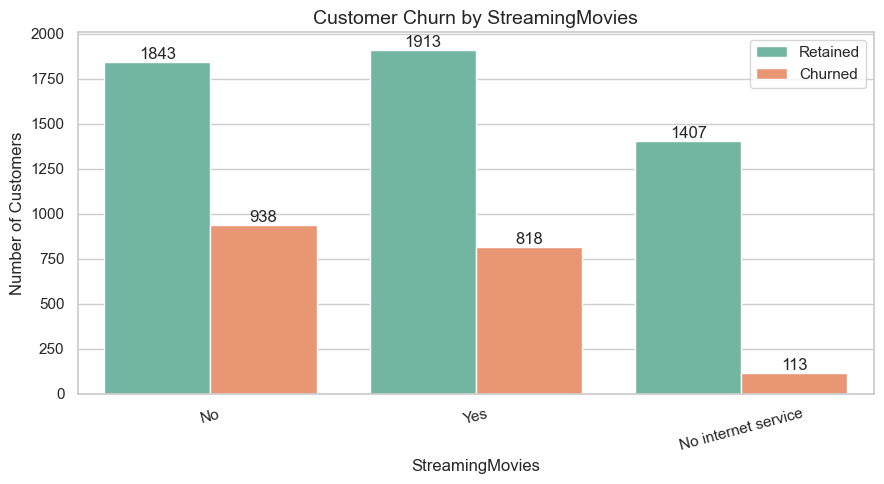


Churn Rate (%)
StreamingMovies
No                     33.73
No internet service     7.43
Yes                    29.95
Name: Churn, dtype: float64


In [49]:
plot_churn("StreamingMovies")

In [50]:
service_summary = pd.DataFrame({

    "Feature":[
        "Fiber Internet",
        "No Online Security",
        "No Tech Support",
        "No Online Backup",
        "No Device Protection"
    ],

    "Business Interpretation":[
        "Highest churn",
        "Higher churn",
        "Higher churn",
        "Higher churn",
        "Higher churn"
    ]

})

service_summary

,Feature,Business Interpretation
0,Fiber Internet,Highest churn
1,No Online Security,Higher churn
2,No Tech Support,Higher churn
3,No Online Backup,Higher churn
4,No Device Protection,Higher churn


## 5.6 Numerical Feature Analysis

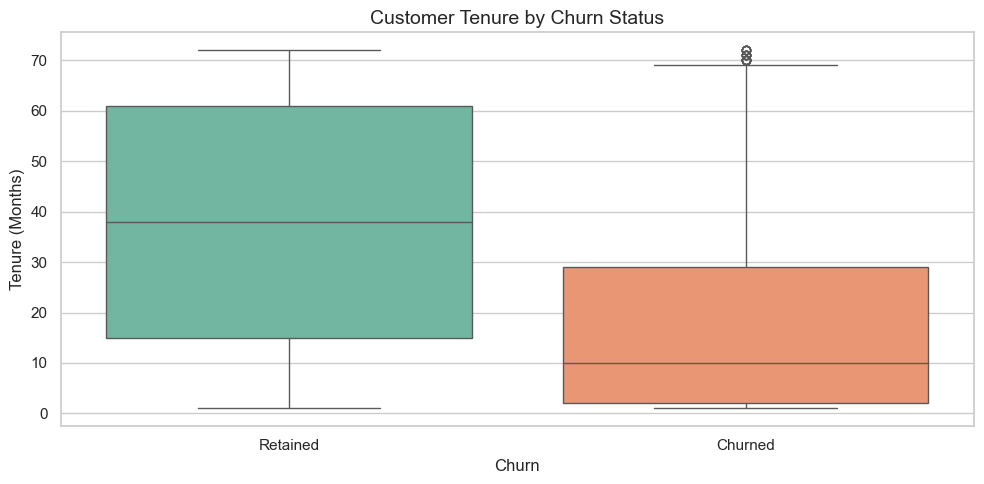

In [51]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="tenure",
    palette="Set2"
)

plt.title("Customer Tenure by Churn Status", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.xticks([0,1],["Retained","Churned"])

plt.tight_layout()

plt.show()

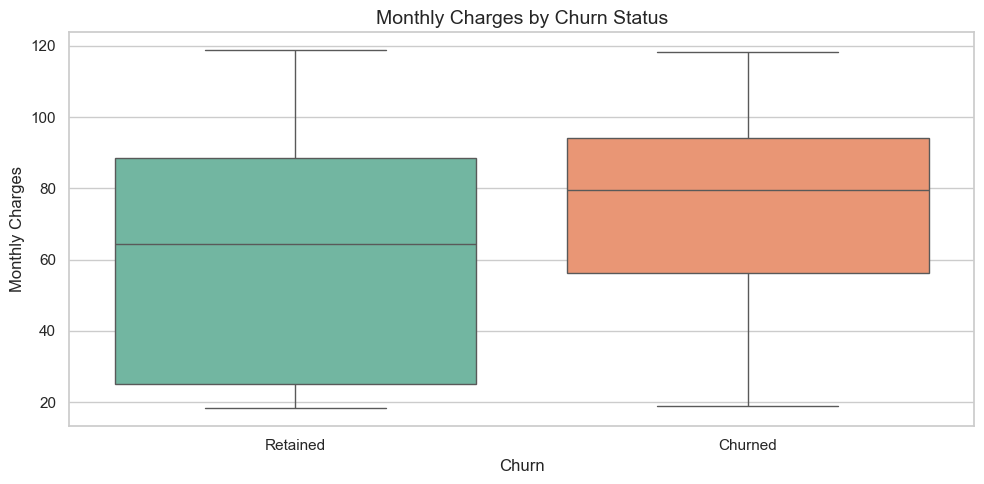

In [52]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges",
    palette="Set2"
)

plt.title("Monthly Charges by Churn Status", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.xticks([0,1],["Retained","Churned"])

plt.tight_layout()

plt.show()

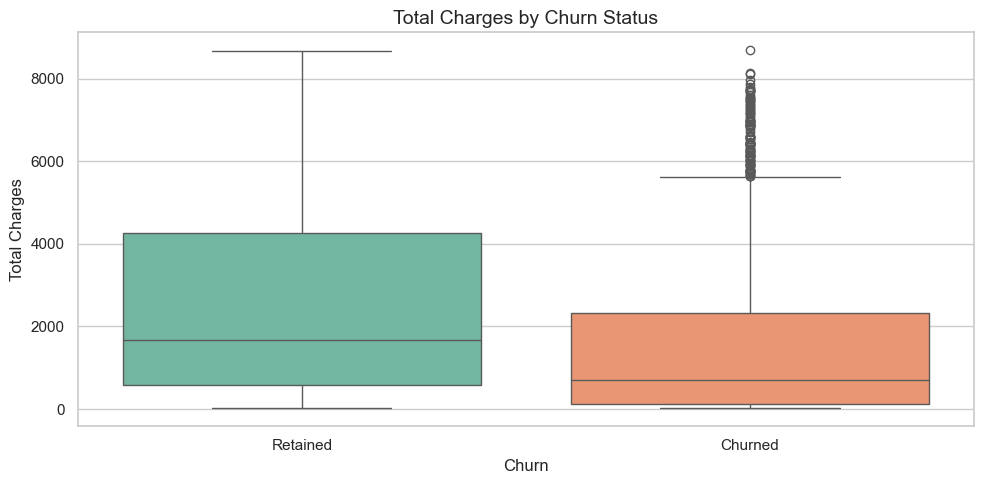

In [53]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="TotalCharges",
    palette="Set2"
)

plt.title("Total Charges by Churn Status", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.xticks([0,1],["Retained","Churned"])

plt.tight_layout()

plt.show()

In [54]:
df_corr = df_clean.copy()

binary_mapping = {
    "Yes": 1,
    "No": 0,
    "Male": 1,
    "Female": 0
}

for col in df_corr.columns:
    if df_corr[col].dtype == "object":
        unique_values = df_corr[col].unique()

        if set(unique_values).issubset({"Yes", "No"}):
            df_corr[col] = df_corr[col].map({"Yes":1,"No":0})

        elif set(unique_values).issubset({"Male","Female"}):
            df_corr[col] = df_corr[col].map({"Male":1,"Female":0})

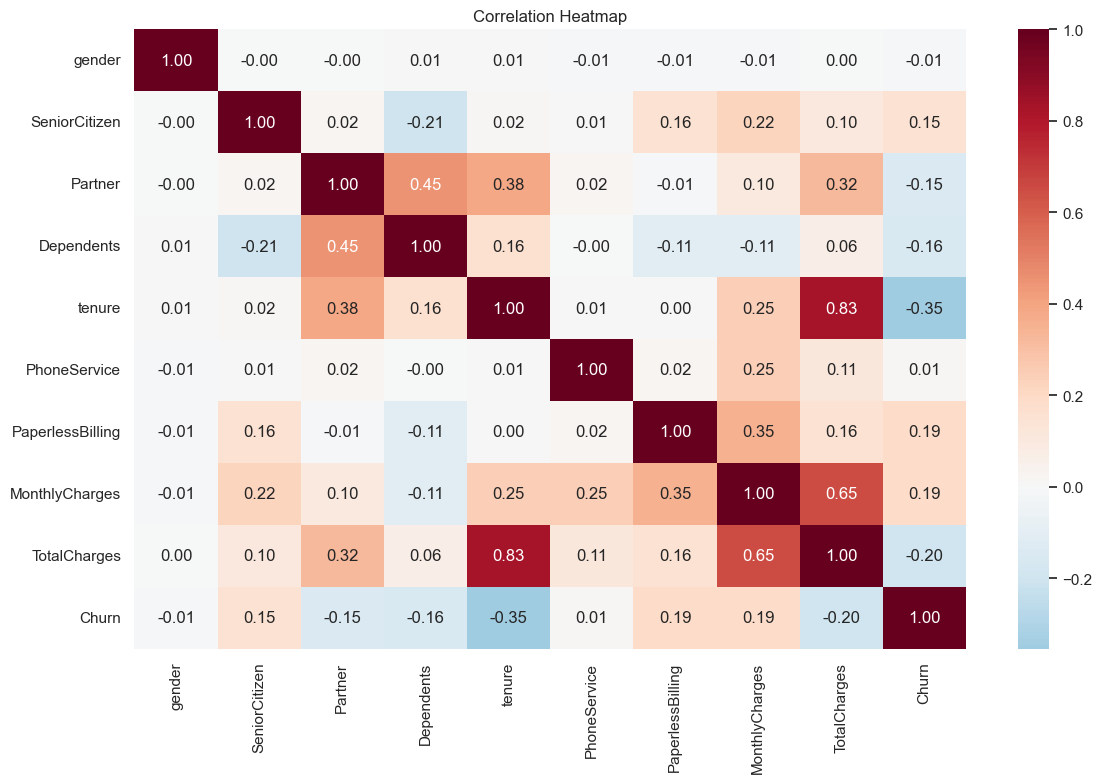

In [55]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_corr.corr(numeric_only=True),
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

## 5.6 Summary

In [56]:
eda_summary = pd.DataFrame({

    "Finding":[
        "Short tenure customers",
        "Higher monthly charges",
        "Long-term customers",
        "Month-to-month contracts",
        "No Tech Support",
        "No Online Security"
    ],

    "Business Impact":[
        "Higher churn",
        "Higher churn",
        "Lower churn",
        "Highest churn",
        "Higher churn",
        "Higher churn"
    ]

})

eda_summary

,Finding,Business Impact
0,Short tenure customers,Higher churn
1,Higher monthly charges,Higher churn
2,Long-term customers,Lower churn
3,Month-to-month contracts,Highest churn
4,No Tech Support,Higher churn
5,No Online Security,Higher churn


# 6. Feature Engineering & Data Preprocessing

In [57]:
df_model = pd.get_dummies(
    df_clean,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", df_model.shape)

df_model.head()

Shape after encoding: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [58]:
X = df_model.drop("Churn", axis=1)

y = df_model["Churn"]

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape : (7032, 30)
Target Variable Shape: (7032,)


In [59]:
print(y.value_counts())

print("\nPercentage Distribution")

print(
    (y.value_counts(normalize=True) * 100).round(2)
)

Churn
0    5163
1    1869
Name: count, dtype: int64

Percentage Distribution
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (5625, 30)
Testing Set  : (1407, 30)


In [61]:
train_distribution = (
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Training Distribution (%)")
print(train_distribution)

print("\nTesting Distribution (%)")
print(test_distribution)

Training Distribution (%)
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

Testing Distribution (%)
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


In [62]:
class_ratio = y_train.value_counts(normalize=True)

print(class_ratio)

Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64


# 7. Model Building & Evaluation

In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
model_results = []

def evaluate_model(model, model_name):


    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

 
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    return model


In [64]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

evaluate_model(
    logistic_model,
    "Logistic Regression"
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [65]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

evaluate_model(
    random_forest,
    "Random Forest"
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(f"Scale Positive Weight : {scale_pos_weight:.2f}")

Scale Positive Weight : 2.76


In [67]:
xgb_model = XGBClassifier(

    objective="binary:logistic",

    random_state=42,

    eval_metric="logloss",

    scale_pos_weight=scale_pos_weight,

    learning_rate=0.05,

    max_depth=4,

    n_estimators=300,

    subsample=0.8,

    colsample_bytree=0.8,

    use_label_encoder=False

)

evaluate_model(
    xgb_model,
    "XGBoost"
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [68]:
results_df = pd.DataFrame(model_results)

results_df = results_df.round(4)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False,
    inplace=True
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8031,0.6448,0.5775,0.6093,0.8364
1,XGBoost,0.7370,0.5034,0.7807,0.6122,0.8313
2,Random Forest,0.7868,0.6209,0.5080,0.5588,0.8181


In [69]:
best_model = results_df.loc[
    results_df["ROC-AUC"].idxmax()
]

print("Best Performing Model")
print("-" * 30)

print(best_model)

Best Performing Model
------------------------------
Model        Logistic Regression
Accuracy                  0.8031
Precision                 0.6448
Recall                    0.5775
F1 Score                  0.6093
ROC-AUC                   0.8364
Name: 0, dtype: object


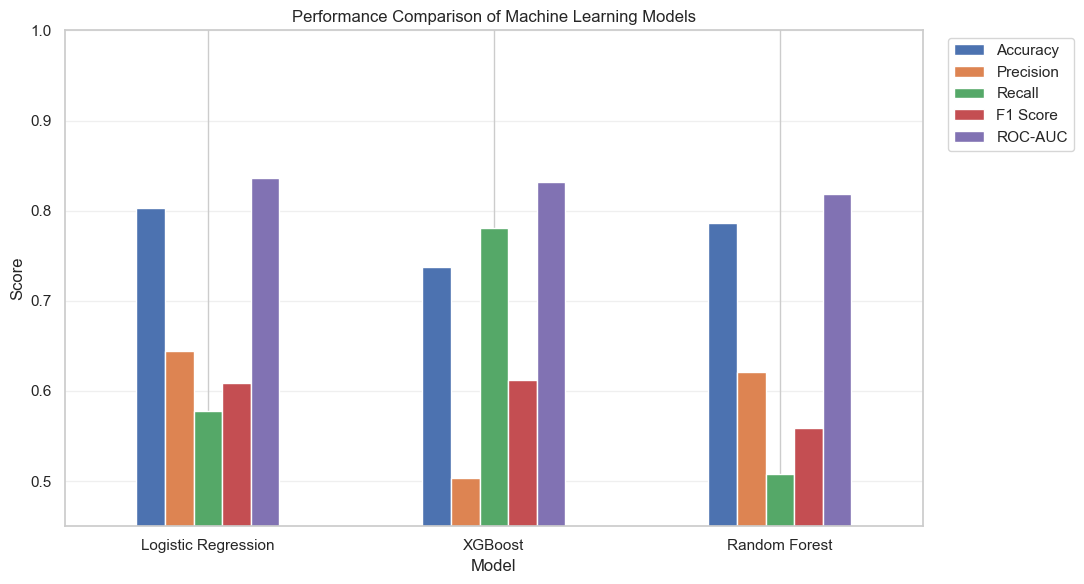

In [70]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison = results_df.set_index("Model")[metrics]

comparison.plot(
    kind="bar",
    figsize=(11,6)
)

plt.title("Performance Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.xlabel("Model")

plt.xticks(rotation=0)

plt.ylim(0.45,1)

plt.grid(axis="y", alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [71]:
best_metrics = pd.DataFrame({

    "Metric": metrics,

    "Best Model": [
        results_df.loc[
            results_df["Accuracy"].idxmax(),
            "Model"
        ],

        results_df.loc[
            results_df["Precision"].idxmax(),
            "Model"
        ],

        results_df.loc[
            results_df["Recall"].idxmax(),
            "Model"
        ],

        results_df.loc[
            results_df["F1 Score"].idxmax(),
            "Model"
        ],

        results_df.loc[
            results_df["ROC-AUC"].idxmax(),
            "Model"
        ]
    ],

    "Score":[

        results_df["Accuracy"].max(),

        results_df["Precision"].max(),

        results_df["Recall"].max(),

        results_df["F1 Score"].max(),

        results_df["ROC-AUC"].max()

    ]

})

best_metrics.round(4)

,Metric,Best Model,Score
0,Accuracy,Logistic Regression,0.8031
1,Precision,Logistic Regression,0.6448
2,Recall,XGBoost,0.7807
3,F1 Score,XGBoost,0.6122
4,ROC-AUC,Logistic Regression,0.8364


# 8. Final Model Evaluation

In [72]:
y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



<Figure size 600x500 with 0 Axes>

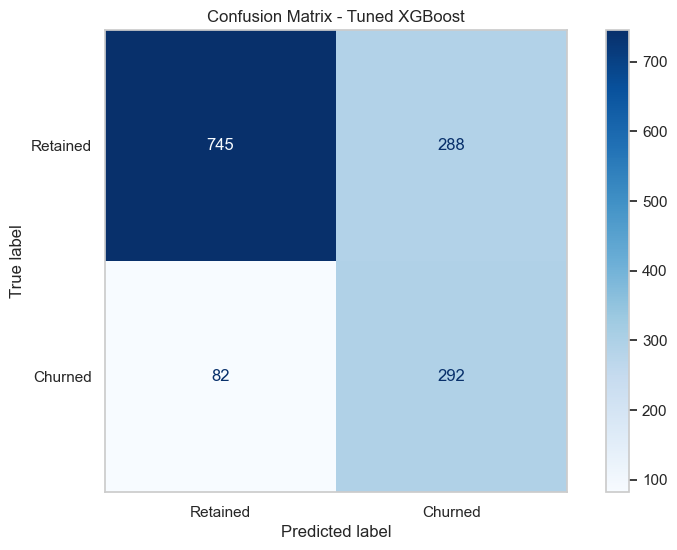

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    display_labels=["Retained", "Churned"]
)

plt.title("Confusion Matrix - Tuned XGBoost")

plt.grid(False)

plt.show()

<Figure size 600x600 with 0 Axes>

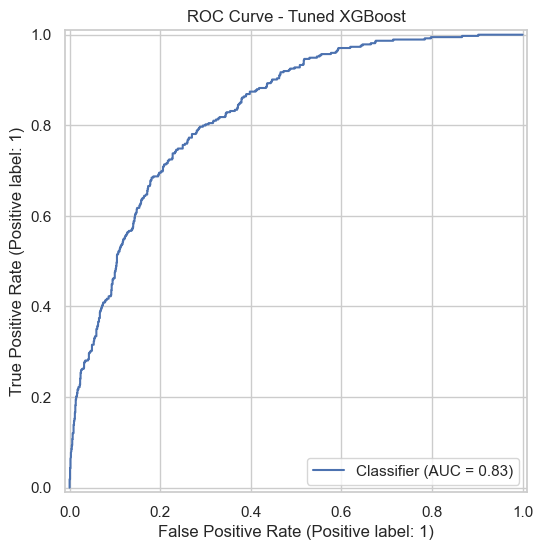

In [74]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(6,6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - Tuned XGBoost")

plt.show()

<Figure size 600x600 with 0 Axes>

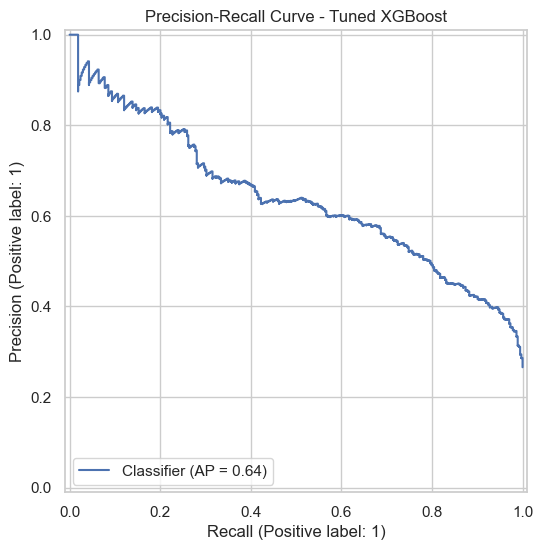

In [75]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(6,6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Precision-Recall Curve - Tuned XGBoost")

plt.show()

In [76]:
performance_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Value":[

        accuracy_score(y_test,y_pred),

        precision_score(y_test,y_pred),

        recall_score(y_test,y_pred),

        f1_score(y_test,y_pred),

        roc_auc_score(y_test,y_prob)

    ]

})

performance_summary.round(4)

,Metric,Value
0,Accuracy,0.7370
1,Precision,0.5034
2,Recall,0.7807
3,F1 Score,0.6122
4,ROC-AUC,0.8313


# 9. Explainable AI (SHAP)

In [77]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
25,Contract_Two year,0.307170
24,Contract_One year,0.149688
10,InternetService_Fiber optic,0.135762
11,InternetService_No,0.067412
12,OnlineSecurity_No internet service,0.037398
28,PaymentMethod_Electronic check,0.031034
23,StreamingMovies_Yes,0.027124
1,tenure,0.022857
8,MultipleLines_No phone service,0.022584
13,OnlineSecurity_Yes,0.019766


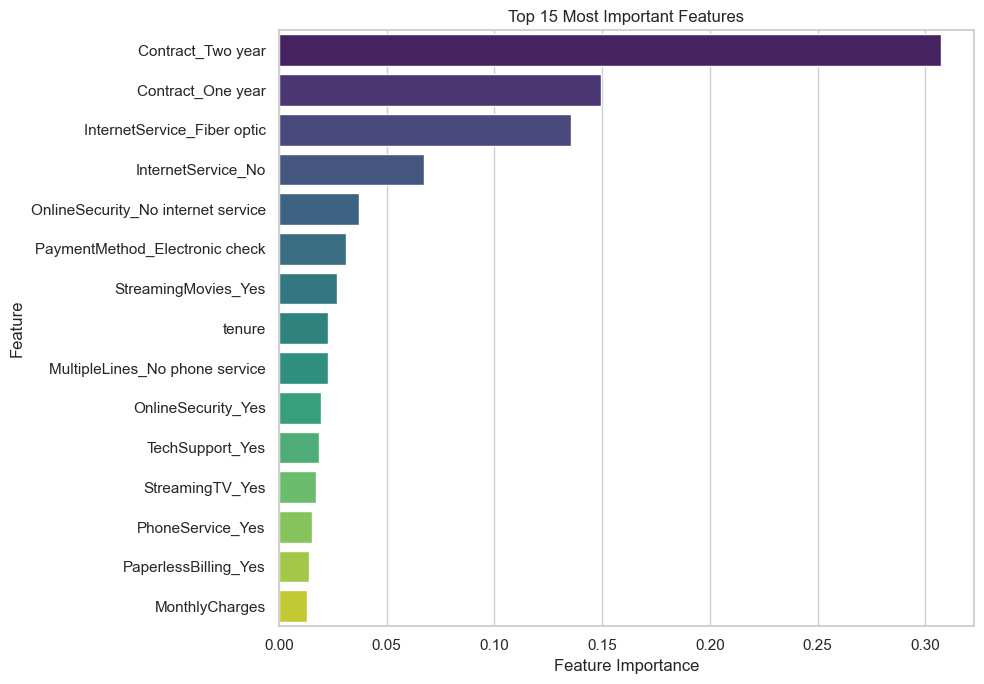

In [78]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Most Important Features")

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [79]:
explainer = shap.Explainer(xgb_model)

shap_values = explainer(X_test)

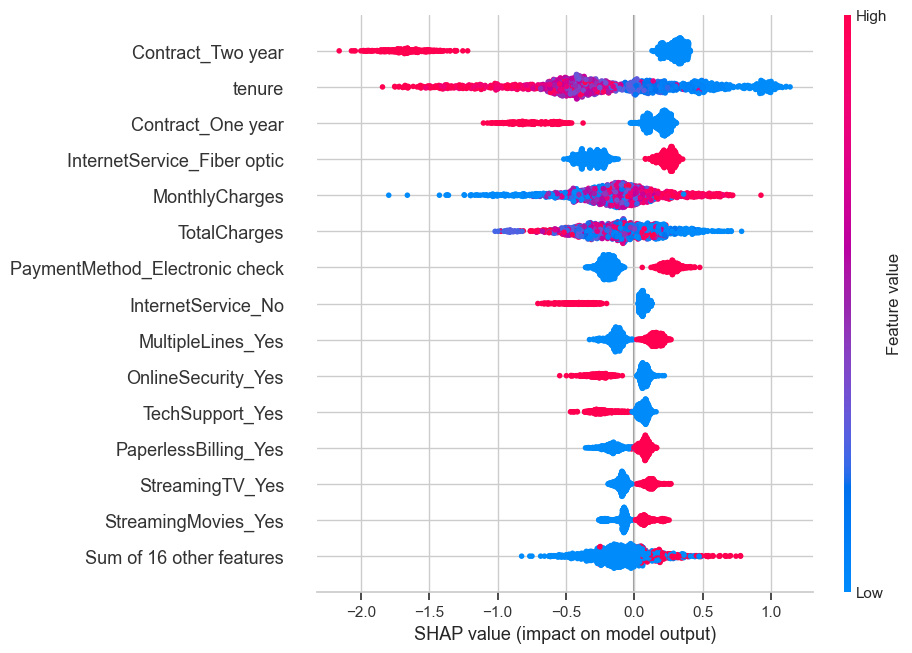

In [80]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

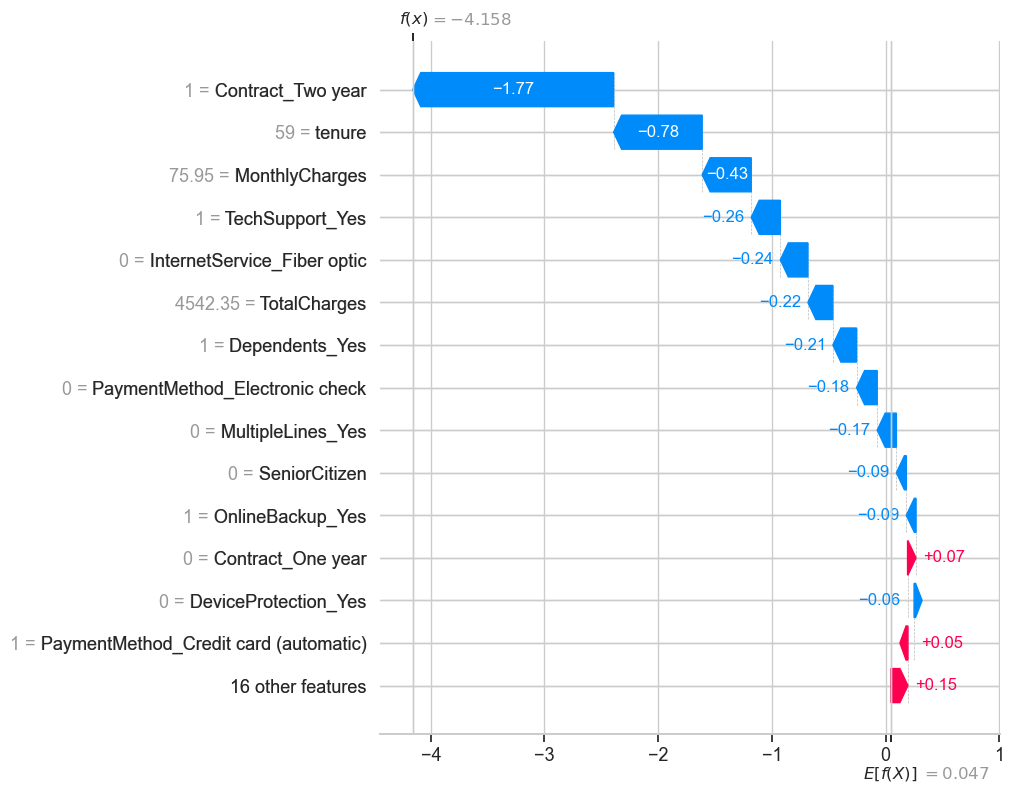

In [81]:
shap.plots.waterfall(
    shap_values[0],
    max_display=15
)

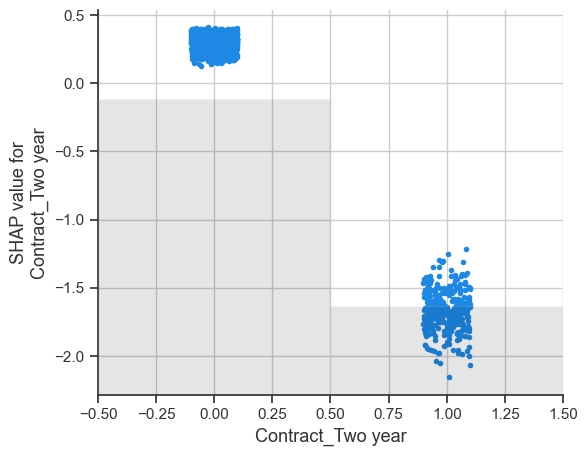

In [82]:
top_feature = feature_importance.iloc[0]["Feature"]

shap.plots.scatter(
    shap_values[:, top_feature]
)

In [83]:
shap_summary = feature_importance.head(10)

shap_summary

,Feature,Importance
25,Contract_Two year,0.307170
24,Contract_One year,0.149688
10,InternetService_Fiber optic,0.135762
11,InternetService_No,0.067412
12,OnlineSecurity_No internet service,0.037398
28,PaymentMethod_Electronic check,0.031034
23,StreamingMovies_Yes,0.027124
1,tenure,0.022857
8,MultipleLines_No phone service,0.022584
13,OnlineSecurity_Yes,0.019766


In [84]:
explainer = shap.Explainer(xgb_model)

shap_values = explainer(X_test)

# 10. Business Insights

In [85]:
business_insights = pd.DataFrame({

    "Insight":[

        "Long-term contracts significantly reduce churn",

        "Fiber Optic customers exhibit higher churn risk",

        "Electronic Check users are more likely to churn",

        "Customers without Online Security have higher churn",

        "New customers (low tenure) are at highest churn risk"

    ],

    "Business Impact":[

        "High",

        "High",

        "Medium",

        "High",

        "High"

    ],

    "Recommended Action":[

        "Promote annual and two-year contract plans",

        "Investigate pricing and service quality",

        "Encourage automatic payment methods",

        "Bundle Online Security with internet plans",

        "Launch onboarding and early retention campaigns"

    ]

})

business_insights

,Insight,Business Impact,Recommended Action
0,Long-term contracts significantly reduce churn,High,Promote annual and two-year contract plans
1,Fiber Optic customers exhibit higher churn risk,High,Investigate pricing and service quality
2,Electronic Check users are more likely to churn,Medium,Encourage automatic payment methods
3,Customers without Online Security have higher ...,High,Bundle Online Security with internet plans
4,New customers (low tenure) are at highest chur...,High,Launch onboarding and early retention campaigns


# 11. Business Recommendations

In [86]:
recommendations = pd.DataFrame({

    "Recommendation":[

        "Promote Long-Term Contracts",

        "Strengthen Customer Onboarding",

        "Bundle Online Security",

        "Improve Fiber Service Experience",

        "Promote Automatic Payments"

    ],

    "Expected Business Benefit":[

        "Reduce contract-related churn",

        "Improve early customer retention",

        "Increase customer loyalty",

        "Reduce dissatisfaction",

        "Reduce payment-related churn"

    ],

    "Priority":[

        "High",

        "High",

        "High",

        "Medium",

        "Medium"

    ]

})

recommendations

,Recommendation,Expected Business Benefit,Priority
0,Promote Long-Term Contracts,Reduce contract-related churn,High
1,Strengthen Customer Onboarding,Improve early customer retention,High
2,Bundle Online Security,Increase customer loyalty,High
3,Improve Fiber Service Experience,Reduce dissatisfaction,Medium
4,Promote Automatic Payments,Reduce payment-related churn,Medium


### Strategic Recommendations

Based on the model outputs and business analysis:

- Increase adoption of annual and two-year subscription plans through targeted discounts or loyalty incentives.
- Launch personalized onboarding campaigns for customers within their first six months.
- Bundle Online Security and Technical Support services with premium internet plans.
- Investigate customer feedback related to Fiber Optic services to improve satisfaction.
- Encourage customers to switch from Electronic Check to automated payment methods.

# 12. Model Deployment

In [87]:
joblib.dump(
    xgb_model,
    "customer_churn_xgboost.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# 13. Conclusion

This project developed an end-to-end customer churn prediction pipeline using Python and XGBoost.

The workflow included:

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Machine Learning Model Development
- Model Evaluation
- Explainable AI using SHAP
- Business Insights
- Strategic Recommendations

Among the evaluated algorithms, the Tuned XGBoost model was selected based on its strong Recall performance, making it well suited for identifying customers at risk of churn.

The integration of SHAP explainability ensured that model predictions remained transparent and aligned with business understanding, enabling actionable retention strategies.

This project demonstrates the complete lifecycle of a real-world machine learning solution—from raw data to business decision-making.